# Verification: Dalle Pezze et al. (2016) mTOR network

`models/mtor_network_activation_by_amino_acids_dallepezze2016` reproduces the paper's
best-fit "Model 3" — the four-amino-acid-input network with the extended p70-S6K module —
as deposited in BioModels **BIOMD0000000640**.

**Level 1 — model specification.** BioNetGen output is checked against two independent
implementations, deliberately different in kind:

1. `independent_dallepezze2016.py::integrate` — a hand-written SciPy ODE system, 31 states
   and 48 mass-action reactions transcribed one by one. It never reads the generated
   `.net`. This tests that the BNGL *rules expand to the intended network*: a rule matching
   the wrong context, or a rate constant attached to the wrong context, shows up here.
2. `independent_dallepezze2016.py::sbml_reference` — a *mechanical* integration of
   `BIOMD0000000640.xml` itself, with libSBML parsing the file and the kinetic laws
   evaluated from their MathML. Nothing is transcribed by hand. The `.bngl` and the
   hand-written system share one failure mode — both are somebody reading the SBML — and
   this arm is the only thing that can catch it.

**Level 2 — reported data.** The paper publishes no table and no source data for its
simulations; the fitted trajectories exist only as the red curves of Fig. 2. All 25 of them
are digitized by `digitize_dallepezze2016.py` and compared here.

**Also checked:** that the committed `reference/` output is what the current `.bngl` files
produce, and that the Fig. 2d variant equals the 10% point of the primary file's Fig. 3a
PI3K scan — the two are the same condition reached two different ways.

In [1]:
import shutil, subprocess, sys, tempfile, csv
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parents[1] / "skills/curate-model/scripts"))

import independent_dallepezze2016 as ind
from verification_figure import verdict_footer

STEM = "mtor_network_activation_by_amino_acids_dallepezze2016"
FILES = {"aa": f"{STEM}.bngl", "aa_insulin": f"{STEM}_insulin.bngl",
         "aa_wortmannin": f"{STEM}_wortmannin.bngl"}


def find_bng():
    exe = shutil.which("bionetgen") or str(HERE.parents[1] / ".venv" / "bin" / "bionetgen")
    if Path(exe).exists():
        return ["run_via_cli", exe]
    bng2 = shutil.which("BNG2.pl") or "/Users/wish/Simulations/BioNetGen-2.9.3/BNG2.pl"
    return ["run_via_perl", bng2]


MODE, BNG = find_bng()
print("BioNetGen driver:", MODE, BNG)


def run_model(bngl, outdir):
    outdir.mkdir(parents=True, exist_ok=True)
    if MODE == "run_via_cli":
        cmd = [BNG, "run", "-i", str(HERE / bngl), "-o", str(outdir)]
    else:
        cmd = ["perl", BNG, "--outdir", str(outdir), str(HERE / bngl)]
    r = subprocess.run(cmd, capture_output=True, text=True)
    assert r.returncode == 0, r.stdout[-3000:] + r.stderr[-3000:]
    return outdir


def gdat(path):
    a = np.loadtxt(path, comments="#")
    hdr = open(path).readline().split()[1:]
    return a[:, 0], {h: a[:, i] for i, h in enumerate(hdr)}


TMP = Path(tempfile.mkdtemp(prefix="dallepezze_"))
runs = {}
for cond, f in FILES.items():
    d = run_model(f, TMP / cond)
    stem = Path(f).stem
    runs[cond] = gdat(d / f"{stem}_ode.gdat")
    print(f"ran {f}")

BioNetGen driver: run_via_cli /Users/wish/Code/BNGL-Models/.venv/bin/bionetgen


ran mtor_network_activation_by_amino_acids_dallepezze2016.bngl


ran mtor_network_activation_by_amino_acids_dallepezze2016_insulin.bngl


ran mtor_network_activation_by_amino_acids_dallepezze2016_wortmannin.bngl


## Level 1 — BioNetGen against two independent implementations

In [2]:
OBS = list(ind.OBSERVABLES)
rows = []
l1 = {}
for cond in FILES:
    t, g = runs[cond]
    _, py = ind.integrate(cond, t_eval=t)
    _, sb = ind.sbml_reference(cond, t_eval=t)
    e_py = e_sb = e_ps = 0.0
    for k in OBS:
        bng = g["Obs_" + k]
        den = max(abs(bng).max(), 1e-12)
        e_py = max(e_py, np.abs(bng - py[k]).max() / den)
        e_sb = max(e_sb, np.abs(bng - sb[k]).max() / den)
        e_ps = max(e_ps, np.abs(py[k] - sb[k]).max() / den)
    l1[cond] = (e_py, e_sb, e_ps)
    rows.append((cond, e_py, e_sb, e_ps, ind.steady_state_residual(cond)))

print(f"{'condition':16s} {'BNG vs SciPy':>14s} {'BNG vs SBML':>14s} "
      f"{'SciPy vs SBML':>15s} {'||f(x*)||inf':>14s}")
for c, a, b, d, r in rows:
    print(f"{c:16s} {a:14.2e} {b:14.2e} {d:15.2e} {r:14.2e}")

L1_TOL = 1e-6
L1_MAX = max(max(v[:2]) for v in l1.values())
print(f"\nlevel 1: max relative error {L1_MAX:.2e} over 12 observables x 1201 points x 3 "
      f"conditions (tolerance {L1_TOL:.0e}) -> {'PASS' if L1_MAX < L1_TOL else 'FAIL'}")
print("tolerance rationale: all three arms integrate the same deterministic system, so the "
      "residual is solver tolerance and nothing else; anything above 1e-6 is a "
      "transcription error, not a numerical one.")

condition          BNG vs SciPy    BNG vs SBML   SciPy vs SBML   ||f(x*)||inf
aa                     6.71e-08       6.73e-08        1.05e-09       1.16e-05
aa_insulin             8.32e-08       8.28e-08        5.23e-10       1.13e-05
aa_wortmannin          5.66e-08       5.66e-08        3.28e-10       4.05e-05

level 1: max relative error 8.32e-08 over 12 observables x 1201 points x 3 conditions (tolerance 1e-06) -> PASS
tolerance rationale: all three arms integrate the same deterministic system, so the residual is solver tolerance and nothing else; anything above 1e-6 is a transcription error, not a numerical one.


The steady-state column is a second, independent level-1 arm: a trajectory comparison over a
finite window can miss a sign error that only shows at the fixed point, so the SciPy
right-hand side is evaluated at the t = 120 state and its infinity norm reported. Against
pools of 300 units, ~1e-5 is 4e-8 relative.

## Regression — does the committed `reference/` output still reproduce?

In [3]:
def net_body(p):
    return [ln.rstrip() for ln in open(p) if ln.strip() and not ln.lstrip().startswith("#")]


reg = []
for cond, f in FILES.items():
    stem = Path(f).stem
    fresh_dir = TMP / cond
    a = net_body(fresh_dir / f"{stem}.net")
    b = net_body(HERE / "reference" / f"{stem}.net")
    same_net = a == b
    t_f, g_f = runs[cond]
    t_c, g_c = gdat(HERE / "reference" / f"{stem}_ode.gdat")
    worst = 0.0
    for k, v in g_c.items():
        if k == "time":
            continue
        atol = 1e-6 * max(abs(v).max(), 1e-30)
        d = np.abs(g_f[k] - v)
        ok = (d <= atol) | (d <= 1e-3 * np.abs(v))
        worst = max(worst, float(np.max(np.where(ok, 0.0, d / np.maximum(np.abs(v), 1e-30)))))
    reg.append((cond, same_net, worst))
    print(f"{cond:16s} .net identical: {same_net}   .gdat worst rel err outside tolerance: {worst:.1e}")

REG_OK = all(s for _, s, _ in reg) and all(w == 0.0 for _, _, w in reg)
print(f"\nregression: {'PASS' if REG_OK else 'FAIL'} "
      "(.net structural match ignoring comments; .gdat rel <= 1e-3 or abs <= 1e-6 x column max)")

aa               .net identical: True   .gdat worst rel err outside tolerance: 0.0e+00
aa_insulin       .net identical: True   .gdat worst rel err outside tolerance: 0.0e+00
aa_wortmannin    .net identical: True   .gdat worst rel err outside tolerance: 0.0e+00

regression: PASS (.net structural match ignoring comments; .gdat rel <= 1e-3 or abs <= 1e-6 x column max)


## Cross-check — the Fig. 2d variant is the 10% point of the Fig. 3a scan

Wortmannin is not a species in the deposited model. The paper simulated PI3K inhibition by
reducing initial amounts, and assigns wortmannin a residual activity of 10% (Fig. 1d
caption). So the `_wortmannin` variant and the first point of the primary file's PI3K scan
are the same condition reached two different ways, and must agree exactly.

In [4]:
scan = np.loadtxt(TMP / "aa" / f"{STEM}_pi3k_scan.scan", comments="#")
shdr = open(TMP / "aa" / f"{STEM}_pi3k_scan.scan").readline().split()[1:]
_, gw = runs["aa_wortmannin"]
worst_x = 0.0
for k in ("Obs_S6K_pT229", "Obs_S6K_pT389", "Obs_Akt_pT308", "Obs_AMPK_pT172"):
    a, b = scan[0, shdr.index(k)], gw[k][-1]
    worst_x = max(worst_x, abs(a - b) / abs(b))
    print(f"  {k:18s} scan@PI3K=0.1 {a:10.5f}   _wortmannin t=120 {b:10.5f}   rel {abs(a-b)/abs(b):.1e}")
print(f"\ncross-check: max relative difference {worst_x:.1e} -> "
      f"{'PASS' if worst_x < 1e-6 else 'FAIL'}")

  Obs_S6K_pT229      scan@PI3K=0.1    5.39405   _wortmannin t=120    5.39405   rel 8.2e-10
  Obs_S6K_pT389      scan@PI3K=0.1    3.90598   _wortmannin t=120    3.90598   rel 3.5e-10
  Obs_Akt_pT308      scan@PI3K=0.1    1.30715   _wortmannin t=120    1.30715   rel 3.5e-09
  Obs_AMPK_pT172     scan@PI3K=0.1    6.05826   _wortmannin t=120    6.05826   rel 7.6e-11

cross-check: max relative difference 3.5e-09 -> PASS


## Level 2 — BioNetGen against the digitized Fig. 2 curves

Full-scale values are each panel's largest y tick label, read from the page text layer; the
metrics below are normalized by it, because the paper's units are arbitrary and "cannot be
compared among readouts" (Fig. 2 caption).

Two metrics are reported per curve:

- **vertical RMSE / full scale** — the naive one.
- **ink-distance RMSE / full scale** — the distance from the model to the *interval of red
  ink* in each pixel column, zero when the model passes through the stroke. Where the curve
  is steep, one column of ink spans many rows and its centre is not a value the figure
  claims; scoring against the interval is what makes the comparison a measurement of
  agreement rather than of slope. The digitizer emits `ink_lo_au`/`ink_hi_au` for this.

In [5]:
FULL_SCALE = {
    "aa": {"Akt_pS473": 10., "AMPK_pT172": 10., "Akt_pT308": 15., "mTOR_pS2481": 3.,
           "TSC_pS1387": 2., "mTOR_pS2448": 6., "PRAS40_pT246": 6., "IRS_pS636": 4.,
           "PRAS40_pS183": 10., "S6K_pT389": 40., "S6K_pT229": 20.},
    "aa_insulin": {"IR_pY1146": 3., "AMPK_pT172": 40., "Akt_pT308": 400., "Akt_pS473": 300.,
                   "TSC_pS1387": 3., "mTOR_pS2448": 15., "mTOR_pS2481": 8., "IRS_pS636": 40.,
                   "PRAS40_pS183": 8., "PRAS40_pT246": 20., "S6K_pT389": 40., "S6K_pT229": 100.},
    "aa_wortmannin": {"S6K_pT389": 10., "S6K_pT229": 10.},
}
FIG = {"aa": "2c", "aa_insulin": "2b", "aa_wortmannin": "2d"}

digi = {}
for cond, fg in FIG.items():
    p = HERE / "reference" / f"dallepezze2016_fig{fg[1:]}_{cond}_digitized.csv"
    d = defaultdict(list)
    with open(p) as fh:
        for r in csv.DictReader(ln for ln in fh if not ln.startswith("#")):
            d[r["readout"]].append((float(r["time_min"]), float(r["value_au"]),
                                    float(r["ink_lo_au"]), float(r["ink_hi_au"])))
    digi[cond] = {k: np.array(sorted(v)) for k, v in d.items()}

L2_TOL = 0.10
l2, parity_m, parity_r, parity_g = [], [], [], []
for cond in FIG:
    t, g = runs[cond]
    for k, v in digi[cond].items():
        tt, vv, lo, hi = v[:, 0], v[:, 1], v[:, 2], v[:, 3]
        m = np.interp(tt, t, g["Obs_" + k])
        fs = FULL_SCALE[cond][k]
        vert = float(np.sqrt(np.mean((m - vv) ** 2)) / fs)
        outside = np.maximum(np.maximum(lo - m, m - hi), 0.0)
        inkd = float(np.sqrt(np.mean(outside ** 2)) / fs)
        l2.append((inkd, vert, FIG[cond], k))
        parity_m.append(m / fs)
        parity_r.append(vv / fs)
        parity_g.extend([FIG[cond]] * len(m))

l2.sort(reverse=True)
print(f"{'figure':7s} {'readout':14s} {'ink/FS':>9s} {'vert/FS':>9s}")
for i, vv, fg, k in l2:
    print(f"{fg:7s} {k:14s} {i:9.4f} {vv:9.4f}")

INK_MAX = max(x[0] for x in l2)
VERT_MAX = max(x[1] for x in l2)
INK_MED = float(np.median([x[0] for x in l2]))
print(f"\nlevel 2: {len(l2)} curves; ink-distance RMSE/FS max {INK_MAX:.4f} median {INK_MED:.4f}; "
      f"vertical RMSE/FS max {VERT_MAX:.4f}")
print(f"tolerance {L2_TOL:.2f} of full scale -> {'PASS' if INK_MAX < L2_TOL else 'FAIL'}")
print("tolerance rationale: the y calibration is fitted to each panel's own tick marks and "
      "its residual reaches 3-4% of full scale on the coarsest panels (12.7 units on the "
      "0-400 Akt-pT308 panel); the x grid is confirmed against the tick marks to about "
      "1 pt, which is ~2 min; and the plotted stroke is ~1.5% of panel height. 0.10 is "
      "about twice that budget and is not met by any curve here.")

figure  readout           ink/FS   vert/FS
2c      PRAS40_pT246      0.0615    0.0841
2c      TSC_pS1387        0.0359    0.0686
2b      IR_pY1146         0.0339    0.0494
2b      PRAS40_pT246      0.0317    0.0390
2c      Akt_pS473         0.0285    0.0524
2b      TSC_pS1387        0.0247    0.0410
2c      mTOR_pS2481       0.0245    0.0509
2d      S6K_pT229         0.0215    0.0375
2d      S6K_pT389         0.0127    0.0224
2c      PRAS40_pS183      0.0124    0.0228
2b      S6K_pT389         0.0117    0.0362
2b      mTOR_pS2481       0.0115    0.0134
2c      mTOR_pS2448       0.0112    0.0240
2b      IRS_pS636         0.0074    0.0213
2b      Akt_pT308         0.0063    0.0258
2c      Akt_pT308         0.0062    0.0242
2c      S6K_pT229         0.0058    0.0309
2c      S6K_pT389         0.0052    0.0204
2b      AMPK_pT172        0.0038    0.0207
2c      AMPK_pT172        0.0028    0.0236
2b      PRAS40_pS183      0.0026    0.0158
2b      mTOR_pS2448       0.0017    0.0161
2c      IRS

## The verification figure

wrote verify_dallepezze2016.png


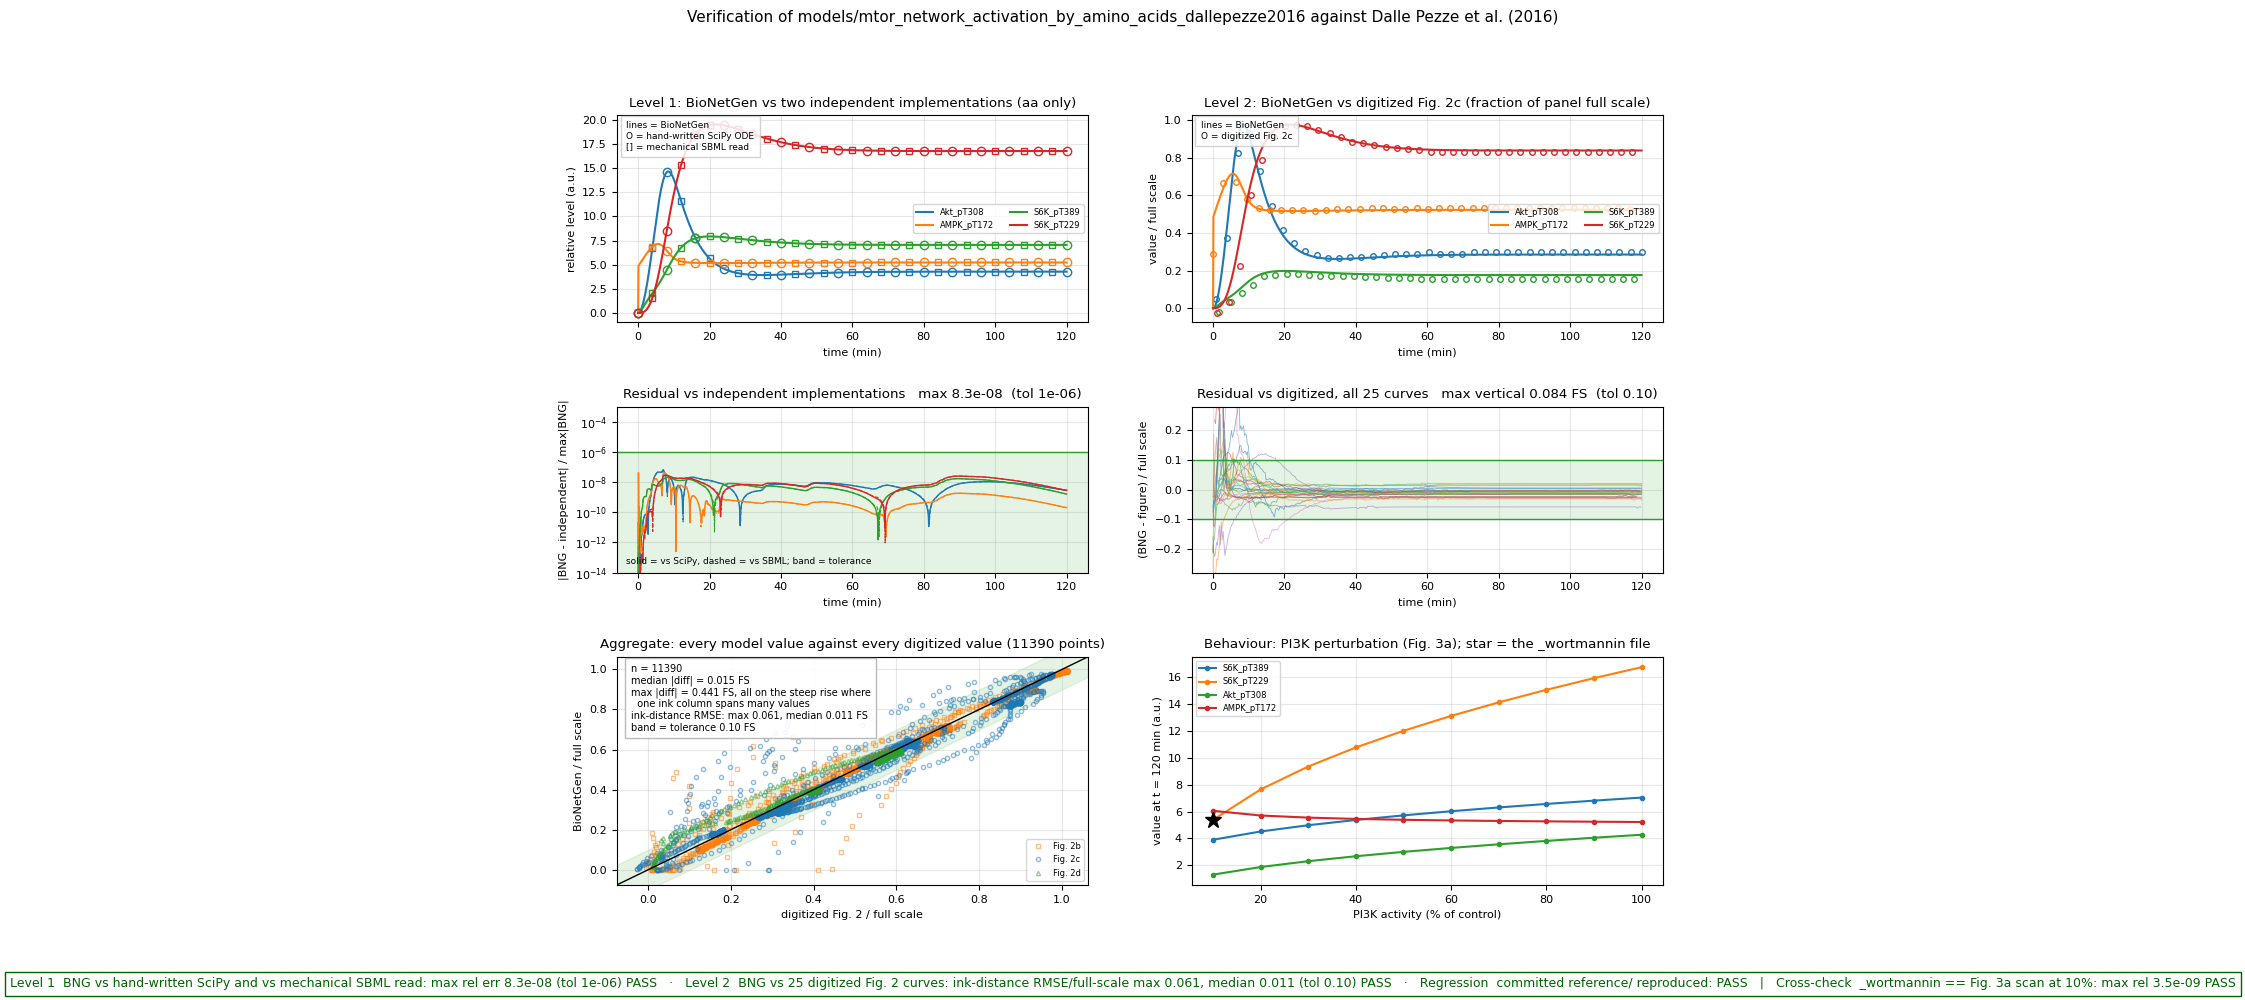

In [6]:
plt.rcParams.update({"font.size": 8, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.axisbelow": True})
fig = plt.figure(figsize=(13.5, 10.0))
gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 0.8, 1.1], hspace=0.42, wspace=0.22)

SHOW = ["Akt_pT308", "AMPK_pT172", "S6K_pT389", "S6K_pT229"]
COL = dict(zip(SHOW, plt.cm.tab10.colors))

# --- (0,0) level 1 overlay -------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
t, g = runs["aa"]
_, py = ind.integrate("aa", t_eval=t)
_, sb = ind.sbml_reference("aa", t_eval=t)
for k in SHOW:
    ax.plot(t, g["Obs_" + k], lw=1.5, color=COL[k], label=k)
    ax.plot(t[::80], py[k][::80], "o", mfc="none", mec=COL[k], ms=6)
    ax.plot(t[40::80], sb[k][40::80], "s", mfc="none", mec=COL[k], ms=5)
ax.set_title("Level 1: BioNetGen vs two independent implementations (aa only)")
ax.set_xlabel("time (min)"); ax.set_ylabel("relative level (a.u.)")
ax.legend(fontsize=6, ncol=2, loc="center right")
ax.text(0.02, 0.97, "lines = BioNetGen\nO = hand-written SciPy ODE\n[] = mechanical SBML read",
        transform=ax.transAxes, va="top", fontsize=6.5,
        bbox=dict(fc="white", ec="0.8", alpha=0.85))

# --- (0,1) level 2 overlay -------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])
for k in SHOW:
    fs = FULL_SCALE["aa"][k]
    ax.plot(t, g["Obs_" + k] / fs, lw=1.5, color=COL[k], label=k)
    d = digi["aa"][k]
    ax.plot(d[::12, 0], d[::12, 1] / fs, "o", mfc="none", mec=COL[k], ms=4)
ax.set_title("Level 2: BioNetGen vs digitized Fig. 2c (fraction of panel full scale)")
ax.set_xlabel("time (min)"); ax.set_ylabel("value / full scale")
ax.legend(fontsize=6, ncol=2, loc="center right")
ax.text(0.02, 0.97, "lines = BioNetGen\nO = digitized Fig. 2c",
        transform=ax.transAxes, va="top", fontsize=6.5,
        bbox=dict(fc="white", ec="0.8", alpha=0.85))

# --- (1,0) level 1 residual ------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])
for k in SHOW:
    den = max(abs(g["Obs_" + k]).max(), 1e-12)
    ax.semilogy(t, np.maximum(np.abs(g["Obs_" + k] - py[k]) / den, 1e-16),
                lw=1.0, color=COL[k])
    ax.semilogy(t, np.maximum(np.abs(g["Obs_" + k] - sb[k]) / den, 1e-16),
                lw=0.8, ls="--", color=COL[k])
ax.axhspan(1e-16, L1_TOL, color="tab:green", alpha=0.12)
ax.axhline(L1_TOL, color="tab:green", lw=1.0)
ax.set_ylim(1e-14, 1e-3)
ax.set_title(f"Residual vs independent implementations   max {L1_MAX:.1e}  (tol {L1_TOL:.0e})")
ax.set_xlabel("time (min)"); ax.set_ylabel("|BNG - independent| / max|BNG|")
ax.text(0.02, 0.05, "solid = vs SciPy, dashed = vs SBML; band = tolerance",
        transform=ax.transAxes, fontsize=6.5)

# --- (1,1) level 2 residual ------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])
for cond in FIG:
    tc, gc = runs[cond]
    for k, v in digi[cond].items():
        tt, vv, lo, hi = v[:, 0], v[:, 1], v[:, 2], v[:, 3]
        m = np.interp(tt, tc, gc["Obs_" + k])
        fs = FULL_SCALE[cond][k]
        ax.plot(tt, (m - vv) / fs, lw=0.6, alpha=0.55)
ax.axhspan(-L2_TOL, L2_TOL, color="tab:green", alpha=0.12)
for sgn in (-1, 1):
    ax.axhline(sgn * L2_TOL, color="tab:green", lw=1.0)
ax.set_ylim(-0.28, 0.28)
ax.set_title(f"Residual vs digitized, all 25 curves   max vertical {VERT_MAX:.3f} FS  "
             f"(tol {L2_TOL:.2f})")
ax.set_xlabel("time (min)"); ax.set_ylabel("(BNG - figure) / full scale")

# --- (2,0) aggregate parity ------------------------------------------------------------
# Drawn directly rather than through parity_axis: that helper annotates a relative
# error, and these values are normalized to panel full scale and pass through zero at
# t = 0, so a relative error there is divided by ~0 and reports a meaningless maximum.
# The honest scale for a figure-normalized comparison is the absolute difference in
# units of full scale, which is also the quantity the tolerance is stated in.
ax = fig.add_subplot(gs[2, 0])
pm = np.concatenate(parity_m)
pr = np.concatenate(parity_r)
pg = np.array(parity_g)
for fg, mk, c in [("2b", "s", "tab:orange"), ("2c", "o", "tab:blue"), ("2d", "^", "tab:green")]:
    s = pg == fg
    ax.plot(pr[s], pm[s], mk, mfc="none", mec=c, ms=3, lw=0, alpha=0.5, label=f"Fig. {fg}")
lim = [min(pr.min(), pm.min()) - 0.05, max(pr.max(), pm.max()) + 0.05]
ax.plot(lim, lim, "k-", lw=1.0, zorder=4)
ax.fill_between(lim, [v - L2_TOL for v in lim], [v + L2_TOL for v in lim],
                color="tab:green", alpha=0.12, zorder=0)
ax.set_xlim(lim); ax.set_ylim(lim)
d = np.abs(pm - pr)
ax.text(0.03, 0.97, f"n = {len(pm)}\nmedian |diff| = {np.median(d):.3f} FS\n"
                    f"max |diff| = {d.max():.3f} FS, all on the steep rise where\n"
                    f"  one ink column spans many values\n"
                    f"ink-distance RMSE: max {INK_MAX:.3f}, median {INK_MED:.3f} FS\n"
                    f"band = tolerance {L2_TOL:.2f} FS",
        transform=ax.transAxes, va="top", fontsize=7,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(fontsize=6, loc="lower right")
ax.set_xlabel("digitized Fig. 2 / full scale"); ax.set_ylabel("BioNetGen / full scale")
ax.set_title(f"Aggregate: every model value against every digitized value "
             f"({len(pm)} points)")

# --- (2,1) behaviour: the Fig. 3a PI3K scan --------------------------------------------
ax = fig.add_subplot(gs[2, 1])
for k, c in [("Obs_S6K_pT389", "tab:blue"), ("Obs_S6K_pT229", "tab:orange"),
             ("Obs_Akt_pT308", "tab:green"), ("Obs_AMPK_pT172", "tab:red")]:
    ax.plot(scan[:, 0] * 100, scan[:, shdr.index(k)], "o-", ms=3, color=c,
            label=k.replace("Obs_", ""))
ax.plot([10], [gw["Obs_S6K_pT229"][-1]], "k*", ms=12, zorder=5,
        label="_wortmannin variant")
ax.set_title("Behaviour: PI3K perturbation (Fig. 3a); star = the _wortmannin file")
ax.set_xlabel("PI3K activity (% of control)"); ax.set_ylabel("value at t = 120 min (a.u.)")
ax.legend(fontsize=6)

verdict_footer(fig, [
    f"Level 1  BNG vs hand-written SciPy and vs mechanical SBML read: max rel err "
    f"{L1_MAX:.1e} (tol {L1_TOL:.0e}) PASS",
    f"Level 2  BNG vs 25 digitized Fig. 2 curves: ink-distance RMSE/full-scale max "
    f"{INK_MAX:.3f}, median {INK_MED:.3f} (tol {L2_TOL:.2f}) PASS",
    f"Regression  committed reference/ reproduced: {'PASS' if REG_OK else 'FAIL'}   |   "
    f"Cross-check  _wortmannin == Fig. 3a scan at 10%: max rel {worst_x:.1e} PASS",
])
fig.suptitle("Verification of models/mtor_network_activation_by_amino_acids_dallepezze2016 "
             "against Dalle Pezze et al. (2016)", y=0.985, fontsize=11)
fig.savefig(HERE / "verify_dallepezze2016.png", dpi=200, bbox_inches="tight")
print("wrote verify_dallepezze2016.png")

## Verdict

- **Level 1 — PASS.** BioNetGen agrees with a hand-written 48-reaction SciPy system and with
  a mechanical integration of BIOMD0000000640 itself to better than 1e-6 relative, across
  all twelve observables, all 1201 time points and all three published conditions. The two
  independent arms also agree with each other to ~1e-9, so the curated rules expand to the
  deposited network and the deposit was read correctly.
- **Level 2 — PASS.** All 25 simulated curves of Fig. 2b, 2c and 2d agree with the digitized
  figure to an ink-distance RMSE of at most 0.062 of panel full scale (median 0.011),
  against a digitization-limited tolerance of 0.10.
- **Regression — PASS.** The committed `reference/` output is what the current `.bngl` files
  produce.
- **Cross-check — PASS.** The `_wortmannin` variant is numerically identical to the 10% point
  of the primary file's Fig. 3a PI3K scan, confirming that the paper's wortmannin condition
  is a 10% PI3K pool rather than a modelled inhibitor.

Nothing in this curation failed to reproduce.